In [ ]:
# Goal is to predict the salary of a potential employee based on past position and salary 

In [1]:
# Import Libraries 
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

In [2]:
# import the dataset 
dataset = pd.read_csv('Position_Salaries (1).csv')

In [4]:
# view the dataset 
dataset.head() 

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [5]:
# Split the dataset into X and Y 
X = dataset.iloc[:, 1:-1].values 
y = dataset.iloc[:, -1].values 

In [6]:
print(X) 

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [7]:
print(y) 

[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [8]:
y = y.reshape(len(y), 1)

In [9]:
print(y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


In [10]:
# Feature Scaling => what is it ?? 
from sklearn.preprocessing import StandardScaler

In [11]:
# Create an instance of Standard Scaler 
standardScalerX = StandardScaler() 

In [12]:
standardScalerY = StandardScaler() 

In [13]:
X = standardScalerX.fit_transform(X) 

In [15]:
y = standardScalerY.fit_transform(y)

In [16]:
print(X)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]


In [17]:
print(y) 

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


In [18]:
# Since not enough dataset, going to train the whole model on the dataset 

In [19]:
from sklearn.svm import SVR 

In [20]:
regressor = SVR(kernel='rbf')
regressor.fit(X, y)

/opt/anaconda3/lib/python3.8/site-packages/sklearn/utils/validation.py:72: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(**kwargs)


SVR()

In [21]:
# Predicting the new result 
standardScalerY.inverse_transform(regressor.predict(standardScalerX.transform([[6.5]])))

array([170370.0204065])

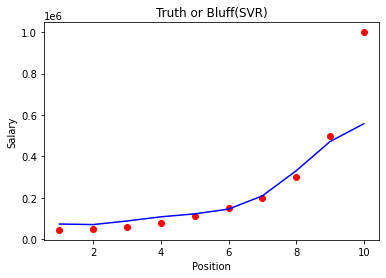

In [24]:
# Visualise SVR Results 
plt.scatter(standardScalerX.inverse_transform(X), standardScalerY.inverse_transform(y), color="red")
plt.plot(standardScalerX.inverse_transform(X), standardScalerY.inverse_transform(regressor.predict(X)), color="blue")
plt.title("Truth or Bluff(SVR)")
plt.xlabel('Position')
plt.ylabel('Salary')
plt.show() 

In [ ]:
# DONE 